# Pronóstico de demanda eléctrica — Gran Buenos Aires (2012-2018)

Predicción de la demanda eléctrica a 1, 2, 3 y 4 días de anticipación para el Gran Buenos Aires (GBA), usando datos horarios reales de CAMMESA, y una descomposición espectral de la señal (ciclo anual, tendencia interanual, ciclo semanal, ciclo diario) usando técnicas de análisis de series de tiempo aplicadas originalmente en oceanografía.

**Fuente de datos:** Maisonnave, Delbianco, Tohme, Maguitman & Milios (2023). *Electricity Energy Consumption in the Gran Buenos Aires (GBA) from 2012 to 2018 — CAMMESA data*. Mendeley Data. [DOI: 10.17632/92g8n7pjp2.1](https://data.mendeley.com/datasets/92g8n7pjp2/1)

**Alcance:** los datos cubren la región del Gran Buenos Aires (GBA), no la demanda nacional argentina completa.

**Estructura del notebook:**
1. Carga y agregación de datos (horario → diario)
2. Análisis exploratorio
3. Descomposición espectral (¿cuánto de la demanda es explicado por ciclos de calendario?)
4. Feature engineering para forecasting
5. Entrenamiento y comparación de modelos
6. Importancia de variables
7. Conclusiones y limitaciones


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
from scipy import signal
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 10
COLOR_DEMANDA = '#2563eb'
COLOR_ACCENT = '#ea580c'
COLOR_GRIS = '#6b7280'


## 1. Carga y agregación de datos

Los datos originales son horarios. Los agregamos a nivel diario: `demand_MWh` como **suma** de las 24 horas (energía total del día), temperaturas como `mean`/`max`/`min` reales calculadas a partir de las lecturas horarias, y el resto de las variables climáticas como promedio diario.

In [2]:
df_horario = pd.read_csv('../data/cammesa_db_2012_2018.csv', parse_dates=['datetime'])
df_horario = df_horario.sort_values('datetime').reset_index(drop=True)
df_horario['fecha'] = df_horario['datetime'].dt.date

df = df_horario.groupby('fecha').agg(
    demand_MWh=('DemGBA', 'sum'),
    tmean=('Temp', 'mean'),
    tmax=('Temp', 'max'),
    tmin=('Temp', 'min'),
    holiday=('Holiday', 'first'),
    viento_y=('vy', 'mean'),
    viento_x=('vx', 'mean'),
    ghi=('GHI', 'mean'),
    humedad=('Hum', 'mean'),
    presion=('Pres', 'mean'),
).reset_index()
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)
df['viento_total'] = np.sqrt(df['viento_x']**2 + df['viento_y']**2)

print(f"{len(df)} dias, de {df['fecha'].min().date()} a {df['fecha'].max().date()}")
df.head()


2557 dias, de 2012-01-01 a 2018-12-31


,fecha,demand_MWh,tmean,tmax,tmin,holiday,viento_y,viento_x,ghi,humedad,presion,viento_total
0,2012-01-01,99924,24.295833,29.3,20.2,True,0.769583,3.617083,384.250000,0.635000,1015.370833,3.698047
1,2012-01-02,134833,27.337500,34.0,21.4,False,1.010833,4.014583,375.875000,0.575000,1012.525000,4.139887
2,2012-01-03,137700,23.150000,26.2,19.4,False,-1.170833,6.880417,359.708333,0.665833,1014.275000,6.979325
3,2012-01-04,132699,23.266667,28.7,16.7,False,2.570833,5.254167,382.250000,0.601667,1016.408333,5.849398
4,2012-01-05,144844,27.508333,32.6,21.8,False,4.598750,-0.172083,377.291667,0.490000,1013.479167,4.601969


## 2. Análisis exploratorio

### 2.1 Serie completa de demanda diaria

Se observa el ciclo estacional (verano/invierno) y una tendencia de crecimiento entre 2012 y 2016, con una leve caída después.

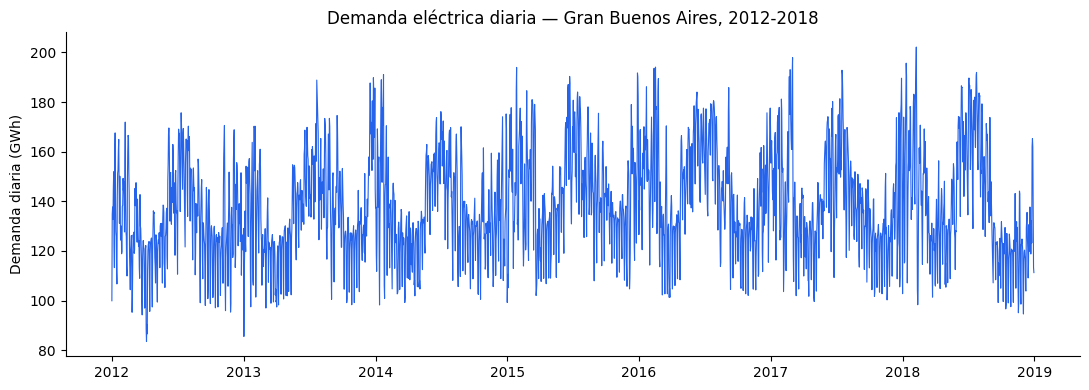

In [3]:
fig, ax = plt.subplots()
ax.plot(df['fecha'], df['demand_MWh']/1000, color=COLOR_DEMANDA, linewidth=0.8)
ax.set_ylabel('Demanda diaria (GWh)')
ax.set_title('Demanda eléctrica diaria — Gran Buenos Aires, 2012-2018')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../figures/01_serie_completa.png', dpi=130)
plt.show()


### 2.2 Perfil horario promedio

La demanda no tiene un único pico diario: hay una meseta al mediodía y un pico más fuerte a la noche (~21hs), con el valle de menor consumo en la madrugada.

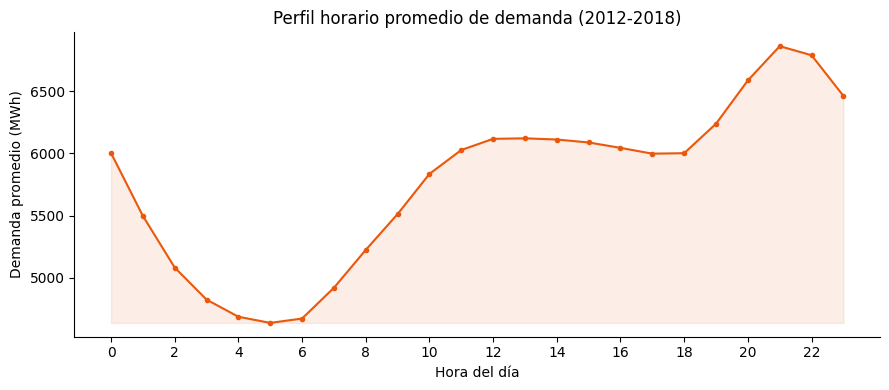

In [4]:
df_horario['hora'] = df_horario['datetime'].dt.hour
perfil = df_horario.groupby('hora')['DemGBA'].mean()

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(perfil.index, perfil.values, color=COLOR_ACCENT, marker='o', markersize=3)
ax.fill_between(perfil.index, perfil.values, perfil.values.min(), color=COLOR_ACCENT, alpha=0.1)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Demanda promedio (MWh)')
ax.set_title('Perfil horario promedio de demanda (2012-2018)')
ax.set_xticks(range(0,24,2))
plt.tight_layout()
plt.savefig('../figures/02_perfil_horario.png', dpi=130)
plt.show()


### 2.3 Demanda: día hábil vs. fin de semana

Confirma el patrón que después el modelo aprende solo: la demanda cae notoriamente los fines de semana.

/tmp/ipykernel_165/3463520953.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=['Día hábil','Fin de semana'], patch_artist=True, widths=0.5)


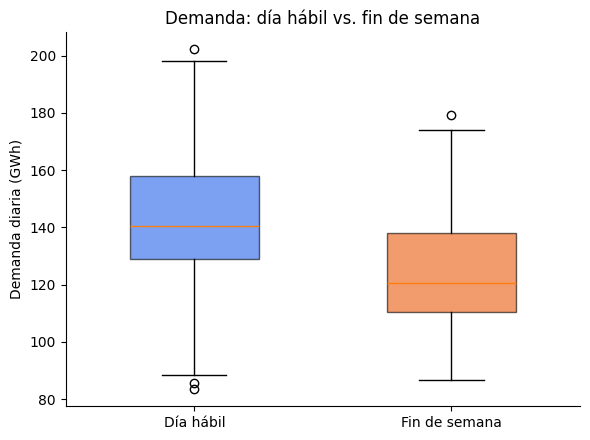

In [5]:
df['es_finde'] = df['fecha'].dt.dayofweek.isin([5,6]).map({True:'Fin de semana', False:'Día hábil'})

fig, ax = plt.subplots(figsize=(6,4.5))
data_box = [df[df['es_finde']=='Día hábil']['demand_MWh']/1000, df[df['es_finde']=='Fin de semana']['demand_MWh']/1000]
bp = ax.boxplot(data_box, labels=['Día hábil','Fin de semana'], patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], [COLOR_DEMANDA, COLOR_ACCENT]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Demanda diaria (GWh)')
ax.set_title('Demanda: día hábil vs. fin de semana')
plt.tight_layout()
plt.savefig('../figures/03_finde_vs_habil.png', dpi=130)
plt.show()


## 3. Descomposición espectral

Pregunta: **¿cuánto de la variabilidad de la demanda se explica por ciclos de calendario (anual, semanal, diario) y cuánto queda sin explicar?**

Cada escala se trata según su forma real, no con una técnica única:
- **Ciclo anual** (365.25 días): tiene una causa física clara y de forma suave (temperatura estacional) → ajuste de onda coseno por cuadrados mínimos.
- **Tendencia interanual**: no es cíclica → filtro Butterworth pasa-bajo (corte 1.5 años).
- **Ciclos semanal (6-8 días) y diario (21-27hs)**: sin forma sinusoidal limpia (patrón "escalón" semanal, doble pico diario) → filtros Butterworth pasa-banda, aplicados con `filtfilt` para no introducir desfase.

**Nota importante:** esta descomposición usa toda la serie (pasado y futuro) para calcular cada punto — es una herramienta exploratoria, no se usa como insumo del modelo de forecasting (eso introduciría fuga de información del futuro).


In [6]:
t_dias = (df['fecha'] - df['fecha'].iloc[0]).dt.total_seconds() / 86400
demanda = df['demand_MWh'].values
media_demanda = demanda.mean()
anomalia = demanda - media_demanda

def onda_anual(t, A, B):
    return A * np.cos(2*np.pi*(1/365.25)*t + B)

popt, _ = curve_fit(onda_anual, t_dias, anomalia, p0=[1,0])
onda_anual_fit = onda_anual(t_dias, *popt)

fs = 1.0
nyq = fs/2
def lowpass(s, periodo_dias, orden=3):
    b, a = signal.butter(orden, (1/periodo_dias)/nyq, btype='lowpass')
    return signal.filtfilt(b, a, s)
def bandpass(s, pmin_dias, pmax_dias, orden=3):
    b, a = signal.butter(orden, [(1/pmax_dias)/nyq, (1/pmin_dias)/nyq], btype='bandpass')
    return signal.filtfilt(b, a, s)

residuo_1 = anomalia - onda_anual_fit
tendencia = lowpass(residuo_1, periodo_dias=1.5*365.25)
residuo_2 = residuo_1 - tendencia
onda_semanal = bandpass(residuo_2, 6, 8)
residuo_3 = residuo_2 - onda_semanal
residuo_final = residuo_3   # a nivel diario no tiene sentido el ciclo de 24hs

componentes = pd.DataFrame({
    'Componente': ['Onda anual', 'Tendencia interanual', 'Onda semanal', 'Residuo'],
    'Desv. estándar (MWh)': [onda_anual_fit.std(), tendencia.std(), onda_semanal.std(), residuo_final.std()],
})
componentes['% de la varianza total'] = (componentes['Desv. estándar (MWh)']**2 / anomalia.var() * 100).round(1)
componentes['Desv. estándar (MWh)'] = componentes['Desv. estándar (MWh)'].round(0)
componentes


,Componente,Desv. estándar (MWh),% de la varianza total
0,Onda anual,4338.0,4.3
1,Tendencia interanual,6581.0,9.9
2,Onda semanal,8997.0,18.4
3,Residuo,18139.0,74.8


**Nota sobre efectos de borde:** el filtro pasa-bajo de la tendencia interanual (corte en 1.5 años) necesita varios ciclos completos para calcular bien los extremos de la serie — los primeros y últimos meses quedan distorsionados por falta de margen, un efecto de borde clásico de `filtfilt`. Siguiendo el mismo criterio que en trabajos previos de series de tiempo, se recortan ~3 meses en cada extremo **solo para esta visualización** (los datos originales y el resto del análisis no se modifican).

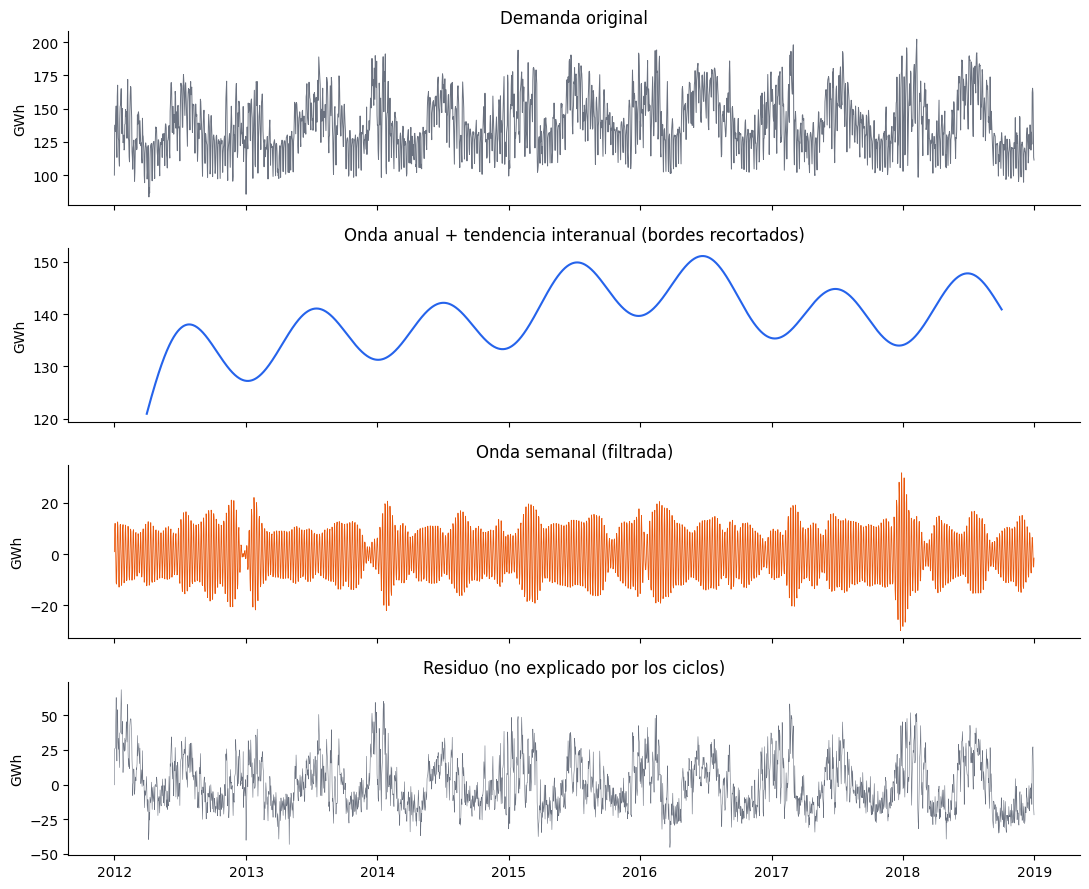

In [7]:
MARGEN_DIAS = 90  # ~3 meses, solo para graficar la tendencia interanual sin el artefacto de borde
recorte = slice(MARGEN_DIAS, -MARGEN_DIAS)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(df['fecha'], demanda/1000, color=COLOR_GRIS, linewidth=0.7)
axes[0].set_title('Demanda original')
axes[1].plot(df['fecha'].iloc[recorte], (media_demanda+onda_anual_fit+tendencia)[recorte]/1000, color=COLOR_DEMANDA)
axes[1].set_title('Onda anual + tendencia interanual (bordes recortados)')
axes[2].plot(df['fecha'], onda_semanal/1000, color=COLOR_ACCENT, linewidth=0.6)
axes[2].set_title('Onda semanal (filtrada)')
axes[3].plot(df['fecha'], residuo_final/1000, color=COLOR_GRIS, linewidth=0.4)
axes[3].set_title('Residuo (no explicado por los ciclos)')
for ax in axes:
    ax.set_ylabel('GWh')
plt.tight_layout()
plt.savefig('../figures/04_descomposicion.png', dpi=130)
plt.show()


## 4. Feature engineering para forecasting

Se predice la demanda a horizontes de **+1, +2, +3 y +4 días**, con un modelo separado por horizonte.

**Simplificación documentada:** se usa el clima real del día objetivo como si fuera el pronóstico ("información perfecta"). En un sistema real, el pronóstico meteorológico tiene su propio margen de error que este proyecto no captura. Se eligió el horizonte máximo de 4 días porque más allá de eso la confiabilidad de los pronósticos meteorológicos reales cae notoriamente.

Variables por horizonte:
- Lo conocido "hoy": `demand_hoy`, `tmean_hoy`
- Clima "pronosticado" del día objetivo: `tmean`, `tmax`, `tmin`, `humedad`, `ghi`, `viento`
- Calendario del día objetivo: `mes`, `es_finde`, `holiday`
- `temp_delta`: diferencia de temperatura hoy → objetivo (para que el modelo aprenda cuándo confiar en `demand_hoy`)


In [8]:
horizontes = [1, 2, 3, 4]

def construir_dataset(h):
    tmp = pd.DataFrame()
    tmp['date_hoy']   = df['fecha']
    tmp['demand_hoy'] = df['demand_MWh']
    tmp['tmean_hoy']  = df['tmean']
    tmp['tmean_obj']  = df['tmean'].shift(-h)
    tmp['tmax_obj']   = df['tmax'].shift(-h)
    tmp['tmin_obj']   = df['tmin'].shift(-h)
    tmp['humedad_obj']= df['humedad'].shift(-h)
    tmp['ghi_obj']    = df['ghi'].shift(-h)
    tmp['viento_obj'] = df['viento_total'].shift(-h)
    tmp['holiday_obj']= df['holiday'].shift(-h).astype('boolean').astype('Int64')
    fecha_obj = df['fecha'].shift(-h)
    tmp['mes_obj']      = fecha_obj.dt.month
    tmp['es_finde_obj'] = fecha_obj.dt.dayofweek.isin([5,6]).astype(int)
    tmp['temp_delta'] = tmp['tmean_obj'] - tmp['tmean_hoy']
    tmp['amplitud_termica_obj'] = tmp['tmax_obj'] - tmp['tmin_obj']
    tmp['target_demand'] = df['demand_MWh'].shift(-h)
    return tmp.dropna().reset_index(drop=True)

datasets = {h: construir_dataset(h) for h in horizontes}
print(f"Ejemplo, horizonte +4: {datasets[4].shape[0]} filas")
datasets[4].head(3)


Ejemplo, horizonte +4: 2551 filas


,date_hoy,demand_hoy,tmean_hoy,tmean_obj,tmax_obj,tmin_obj,humedad_obj,ghi_obj,viento_obj,holiday_obj,mes_obj,es_finde_obj,temp_delta,amplitud_termica_obj,target_demand
0,2012-01-01,99924,24.295833,27.508333,32.6,21.8,0.49,377.291667,4.601969,0,1.0,0,3.212500,10.8,144844.0
1,2012-01-02,134833,27.337500,28.808333,37.9,22.9,0.45,369.666667,7.622972,0,1.0,0,1.470833,15.0,151924.0
2,2012-01-03,137700,23.150000,24.475000,28.6,21.8,0.67,371.708333,11.267200,0,1.0,1,1.325000,6.8,122901.0


## 5. Split temporal y entrenamiento

Split por años completos: **2012-2016 entrenamiento, 2017-2018 test** — nunca al azar, para no filtrar información del futuro. Se comparan 3 modelos: Regresión Lineal (baseline, con `amplitud_térmica` para evitar el problema de multicolinealidad entre `tmax`/`tmin`), Random Forest y Gradient Boosting.

In [9]:
features_lineal  = ['demand_hoy','tmean_hoy','tmean_obj','amplitud_termica_obj','humedad_obj','ghi_obj','viento_obj','mes_obj','es_finde_obj','holiday_obj','temp_delta']
features_arboles = ['demand_hoy','tmean_hoy','tmean_obj','tmax_obj','tmin_obj','humedad_obj','ghi_obj','viento_obj','mes_obj','es_finde_obj','holiday_obj','temp_delta']

# IMPORTANTE: una funcion que crea una instancia NUEVA cada vez que se llama.
# Si en cambio instanciaramos los modelos una sola vez afuera del loop, cada
# .fit() de un horizonte nuevo pisaria el entrenamiento del horizonte anterior,
# porque seguiria siendo el mismo objeto en memoria.
def crear_modelos():
    return {
        'Regresión Lineal':  (LinearRegression(), features_lineal),
        'Random Forest':     (RandomForestRegressor(random_state=42), features_arboles),
        'Gradient Boosting': (GradientBoostingRegressor(random_state=42), features_arboles),
    }

resultados = []
modelos_entrenados = {}

for h in horizontes:
    d = datasets[h]
    train = d[d['date_hoy'].dt.year <= 2016]
    test  = d[d['date_hoy'].dt.year >= 2017]
    for nombre, (modelo, feats) in crear_modelos().items():
        X_train, y_train = train[feats], train['target_demand']
        X_test,  y_test  = test[feats],  test['target_demand']
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        mae  = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mape = np.mean(np.abs((y_test-pred)/y_test))*100
        resultados.append({'horizonte': h, 'modelo': nombre, 'MAE': round(mae,0), 'RMSE': round(rmse,0), 'MAPE_%': round(mape,2)})
        modelos_entrenados[(h, nombre)] = modelo

res = pd.DataFrame(resultados)
res


,horizonte,modelo,MAE,RMSE,MAPE_%
0,1,Regresión Lineal,8379.0,10748.0,5.98
1,1,Random Forest,4465.0,6196.0,3.20
2,1,Gradient Boosting,4262.0,5749.0,3.06
3,2,Regresión Lineal,11759.0,14837.0,8.42
4,2,Random Forest,5899.0,7616.0,4.25
5,2,Gradient Boosting,5927.0,7665.0,4.28
6,3,Regresión Lineal,13591.0,16813.0,9.73
7,3,Random Forest,6634.0,8526.0,4.75
8,3,Gradient Boosting,6619.0,8372.0,4.75
9,4,Regresión Lineal,14268.0,17587.0,10.19


### 5.1 MAPE por modelo y horizonte

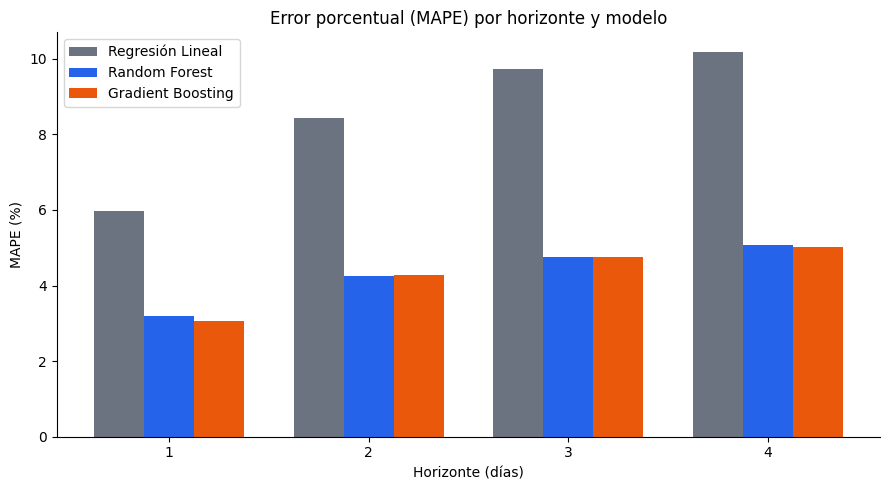

In [10]:
fig, ax = plt.subplots(figsize=(9,5))
ancho = 0.25
colores = {'Regresión Lineal': COLOR_GRIS, 'Random Forest': COLOR_DEMANDA, 'Gradient Boosting': COLOR_ACCENT}
for i, modelo in enumerate(colores):
    sub = res[res['modelo']==modelo]
    ax.bar(sub['horizonte'] + (i-1)*ancho, sub['MAPE_%'], width=ancho, label=modelo, color=colores[modelo])
ax.set_xlabel('Horizonte (días)')
ax.set_ylabel('MAPE (%)')
ax.set_title('Error porcentual (MAPE) por horizonte y modelo')
ax.set_xticks(horizontes)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/05_mape_comparacion.png', dpi=130)
plt.show()


## 6. Importancia de variables

Comparación de importancia de features en Random Forest entre horizonte +1 y +4 — muestra cómo el modelo deja de confiar en `demand_hoy` y pasa a apoyarse en `tmean_obj` a medida que crece el horizonte.

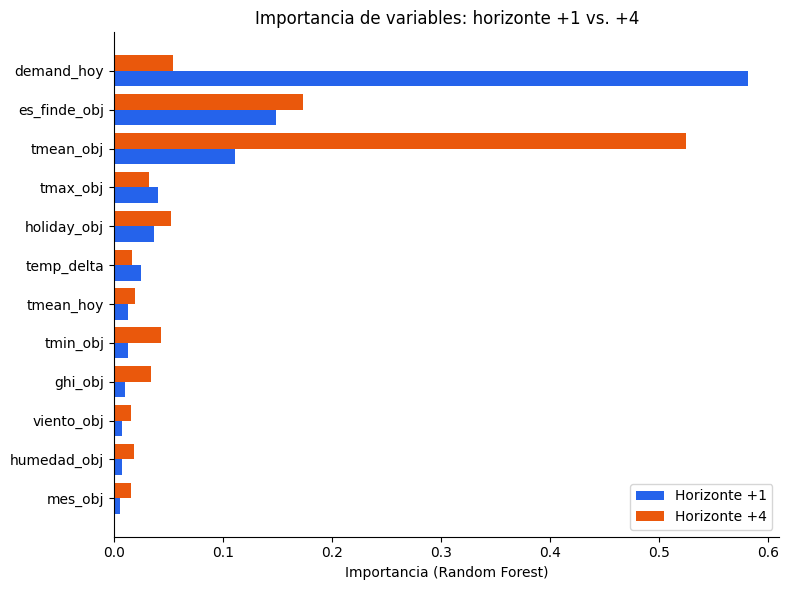

In [11]:
rf_h1 = modelos_entrenados[(1, 'Random Forest')]
rf_h4 = modelos_entrenados[(4, 'Random Forest')]

imp = pd.DataFrame({
    'Horizonte +1': rf_h1.feature_importances_,
    'Horizonte +4': rf_h4.feature_importances_,
}, index=features_arboles).sort_values('Horizonte +1', ascending=True)

fig, ax = plt.subplots(figsize=(8,6))
y_pos = np.arange(len(imp))
ax.barh(y_pos-0.2, imp['Horizonte +1'], height=0.4, label='Horizonte +1', color=COLOR_DEMANDA)
ax.barh(y_pos+0.2, imp['Horizonte +4'], height=0.4, label='Horizonte +4', color=COLOR_ACCENT)
ax.set_yticks(y_pos)
ax.set_yticklabels(imp.index)
ax.set_xlabel('Importancia (Random Forest)')
ax.set_title('Importancia de variables: horizonte +1 vs. +4')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/06_feature_importance.png', dpi=130)
plt.show()


## 7. Conclusiones y limitaciones

**Resultados principales:**
- El mejor modelo (Gradient Boosting / Random Forest, según horizonte) logra un **MAPE de ~3.1% a 1 día** y **~5.0% a 4 días**.
- El error crece de forma consistente con el horizonte, como se esperaba.
- La variable más importante cambia con el horizonte: `demand_hoy` domina a corto plazo (persistencia), la temperatura del día objetivo domina a horizontes más largos.
- La descomposición espectral muestra que los ciclos de calendario (anual, semanal) explican una porción de la variabilidad, pero la mayoría queda en el residuo — de ahí la necesidad de variables climáticas en el modelo de forecasting.

**Limitaciones documentadas:**
- Se usa el clima real del día objetivo como si fuera el pronóstico ("información perfecta") — un sistema real tendría error adicional del propio pronóstico meteorológico.
- El dataset cubre el Gran Buenos Aires (GBA), no la demanda eléctrica nacional de Argentina.
- La variable EMAE (actividad económica) se excluyó por su retraso de publicación real y su baja variabilidad diaria — queda como extensión futura.
- Los datos llegan hasta diciembre 2018 (última versión pública de este dataset específico).
- La descomposición espectral es una herramienta exploratoria, no se usa como insumo del modelo de forecasting (evita fuga de información).

**Próximos pasos posibles:** incorporar EMAE con el rezago real de publicación, extender el dataset con datos más recientes vía la API de ENTSO-E equivalente para Argentina, o explorar horizontes más largos con pronósticos meteorológicos reales en vez de la simplificación de información perfecta.
